# PPO-on-contrastive-critic spin-up: ManiSkill3 PushCube-v1

This is a **pipeline smoke test**, not an attempt to solve the task. The goal is to confirm
`ppo_contrastive.py`'s PPO/CRL training loop runs end-to-end on a real ManiSkill robotic
manipulation env (instead of the point-mass/Sawyer envs it was tuned on), and to watch a
few training metrics move.

Hyperparameters are copied from `slurm_scripts/discount_0p99.slurm` (the tuned point-env
PPO config), with `num_steps` reduced to something reasonable for a first look.

**It's fine to interrupt the kernel (Kernel > Interrupt) at any point after you've seen a
few learner rows print and at least one eval row (which appears every 10 iterations)** —
that's enough to confirm the pipeline works.

Known quirks (not bugs):
- `eval/init_dist`, `final_dist`, `delta_dist`, `min_dist` will be numerically meaningless
  for this env (the generic `DistanceObserver` assumes the goal vector's full length is
  meaningful, but most of ours is zero-padding). Watch `success`, `success_1000`,
  `ep_return_mean`, and `crl/crl_loss` instead.
- No checkpoint will be written during this short a run (`ppo_checkpoint_interval=500`
  exceeds this run's ~290 iterations) — uncomment the override below if you want one.
- This host currently has 1 visible CPU (cgroup-limited) with load average ~9, and
  ManiSkill's CPU-sim env stepping benchmarks at ~1000 steps/sec serially across the 8
  parallel env slots — that's the throughput bottleneck, not JAX/GPU. If it's too slow,
  lower `config.ppo_num_envs` below.

In [9]:
import os

# Must be set before any `jax` import (including transitively).
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.4'

# Installing mani_skill/torch/gymnasium into this conda env pulled in a much
# newer protobuf than the pinned tensorflow==2.8/reverb stack expects, which
# otherwise breaks `import contrastive` with
# `TypeError: Descriptors cannot be created directly.` -- this is the
# standard workaround (falls back to pure-Python protobuf parsing, slightly
# slower but functionally fine; tensorflow/reverb aren't on the PPO hot path).
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

In [10]:
import functools

import sgcrl_jax_acme_compat  # noqa: F401 -- must precede acme/jax imports
import jax

print('jax devices:', jax.devices())
assert jax.devices()[0].platform == 'gpu', (
    'Got a CPU device -- the Jupyter kernel likely did not inherit '
    'LD_LIBRARY_PATH from your shell profile. Restart the kernel from a '
    'login shell that has `conda activate contrastive_rl` sourced (or '
    'export LD_LIBRARY_PATH manually, matching slurm_scripts/discount_0p99.slurm) '
    'and re-run this cell.')

import contrastive
from contrastive import ppo_learner
from contrastive import utils as contrastive_utils
from default import make_default_logger

jax devices: [StreamExecutorGpuDevice(id=0, process_index=0, slice_index=0)]


In [11]:
env_name = 'maniskill_pushcube'
seed = 0

# ppo_num_envs(8) * ppo_rollout_length(128) = 1024 env-steps/iteration ->
# ~293 iterations. At the measured ~1000 env-steps/sec (single-CPU-bound on
# this host) plus periodic eval-env-rebuild overhead, expect roughly
# 1.5-2.5s/iteration once warmed up -> ~10-15 minutes total. Soft estimate;
# interrupt early once you've seen the pipeline produce a few rows.
num_steps = 300_000

params = dict(
    seed=seed,
    env_name=env_name,
    alg_name='ppo',
    reward_shaping_mode='ppo',
    use_cpc=True,
    max_number_of_steps=num_steps,
    log_dir='logs/ppo_pushcube_spinup/',
    add_uid=False,
    fix_goals=True,
)
config = contrastive.ContrastiveConfig(**params)
config.repr_norm = False

# --- hyperparameters copied from slurm_scripts/discount_0p99.slurm ---
config.ppo_crl_steps_per_iter = 64
config.ppo_ent_coef = 0.05
config.ppo_actor_min_std = 0.01
config.ppo_discount = 0.99
config.ppo_clip_coef = 0.2
config.uniform_sampling = True
config.ppo_anneal_lr = True

# --- per-env PPO default (matches PPO_ENV_DEFAULTS['maniskill_pushcube']
# in ppo_contrastive.py: PushCube's 50-step episodes are the same order of
# magnitude as point_FourRooms/point_Spiral*) ---
config.ppo_rollout_length = 128

# Uncomment for a resumable run (default 500 exceeds this run's ~293 iters):
# config.ppo_checkpoint_interval = 50

print(f'[ppo_pushcube_spinup] PPO knobs: '
      f'rollout_length={config.ppo_rollout_length}, '
      f'crl_steps_per_iter={config.ppo_crl_steps_per_iter}, '
      f'num_envs={config.ppo_num_envs}, '
      f'clip_coef={config.ppo_clip_coef}, '
      f'actor_min_std={config.ppo_actor_min_std}, '
      f'ent_coef={config.ppo_ent_coef}, '
      f'discount_ppo={config.ppo_discount}, '
      f'uniform_sampling={config.uniform_sampling}')

[ppo_pushcube_spinup] PPO knobs: rollout_length=128, crl_steps_per_iter=64, num_envs=8, clip_coef=0.2, actor_min_std=0.01, ent_coef=0.05, discount_ppo=0.99, uniform_sampling=True


In [12]:
# PushCube-v1 randomizes cube start + goal region every reset internally,
# so there's no meaningful single fixed goal the way point/Sawyer envs have
# one -- `None` here (and the matching entry in ppo_contrastive.py's
# fixed_goal_dict) just means "let ManiSkill randomize normally".
fixed_goal_dict = {'maniskill_pushcube': None}
fixed_start_end = fixed_goal_dict[env_name] if config.fix_goals else None


def env_factory(s):
  env, _ = contrastive_utils.make_environment(
      env_name, config.start_index, config.end_index, s,
      fixed_start_end=fixed_start_end)
  return env


def eval_env_factory(s):
  env, _ = contrastive_utils.make_environment(
      env_name, config.start_index, config.end_index, s,
      fixed_start_end=fixed_goal_dict[env_name])
  return env


probe_env, obs_dim = contrastive_utils.make_environment(
    env_name, config.start_index, config.end_index, seed,
    fixed_start_end=fixed_start_end)
config.obs_dim = obs_dim
config.max_episode_steps = getattr(probe_env, '_step_limit') + 1
del probe_env
print(f'obs_dim={config.obs_dim}, max_episode_steps={config.max_episode_steps}')

obs_dim=6, max_episode_steps=51


In [13]:
# Same construction as ppo_contrastive.py's network_factory. actor_min_std
# is raised from the shared 1e-6 default to the PPO-specific floor: without
# a hard std floor, the tanh-squashed Gaussian policy collapses to a
# near-point-mass within a handful of PPO updates (SAC gets away with 1e-6
# because adaptive-alpha actively regulates entropy; PPO doesn't).
network_factory = functools.partial(
    contrastive.make_networks,
    obs_dim=obs_dim,
    repr_dim=config.repr_dim,
    repr_norm=config.repr_norm,
    twin_q=config.twin_q,
    use_image_obs=config.use_image_obs,
    hidden_layer_sizes=config.hidden_layer_sizes,
    actor_min_std=float(config.ppo_actor_min_std))

In [14]:
run_dir = os.path.join(config.log_dir, f'{config.alg_name}_{config.env_name}_{seed}')
os.makedirs(run_dir, exist_ok=True)

# print_fn=print is essential here: make_default_logger defaults to
# logging.info, which is silent by default in a notebook. This is what
# makes the training cell below print metrics live (roughly once per
# second, via the logger's built-in TimeFilter).
logger_fn = functools.partial(
    make_default_logger,
    save_dir=run_dir,
    add_uid=config.add_uid,
    steps_key='learner_steps',
    print_fn=print)
checkpoint_dir = os.path.join(run_dir, 'checkpoints')
print(f'run_dir={run_dir}')

run_dir=logs/ppo_pushcube_spinup/ppo_maniskill_pushcube_0


In [15]:
# Blocks the kernel while training, printing learner metrics ~once/sec and
# an eval row every 10 iterations. Interrupt the kernel any time.
ppo_learner.run_ppo_training(
    config=config,
    env_factory=env_factory,
    eval_env_factory=eval_env_factory,
    network_factory=network_factory,
    logger_fn=logger_fn,
    total_steps=num_steps,
    seed=seed,
    checkpoint_dir=checkpoint_dir,
)

[ppo] uniform_sampling: goal_low=[-1. -1. -1. -1. -1. -1.], goal_high=[1. 1. 1. 1. 1. 1.]
[ppo] checkpoints → logs/ppo_pushcube_spinup/ppo_maniskill_pushcube_0/checkpoints (every 500 iters, keep last 5)


[Learner] Advantage Mean = 0.329 | Advantage Std = 0.958 | Crl/Binary Accuracy = nan | Crl/Categorical Accuracy = nan | Crl/Crl Loss = nan | Crl/Logits Neg = nan | Crl/Logits Pos = nan | Crl/Logsumexp = nan | Early Stop Epochs = 0 | Ep Length Mean = 50.000 | Ep Return Mean = 0.000 | Global Step = 1024 | Iteration = 0 | Learner Steps = 0 | Ppo/Approx Kl = 0.008 | Ppo/Clipfrac = 0.103 | Ppo/Entropy = 2.614 | Ppo/Entropy Loss = -0.131 | Ppo/Learning Rate = 0.000 | Ppo/Mean Pg Loss = -0.016 | Ppo/Old Approx Kl = 0.010 | Ppo/Pg Loss = -0.016 | Ppo/Ppo Total Loss = 0.074 | Ppo/Ratio Mean = 0.998 | Ppo/V Loss = 0.442 | Replay Size = 800 | Returns Mean = 0.310 | Reward Env Mean = 0.000 | Reward Repr Mean = 0.038 | Reward Repr Raw Mean = 0.001 | Reward Repr Raw Std = 0.005 | Reward Return Norm Std = 0.067 | Sps = 211.490 | Value Mean = -0.019


/home/gliu2/miniconda3/envs/contrastive_rl/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gliu2/miniconda3/envs/contrastive_rl/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[Eval] Delta Dist = 0.002 | Episode Length = 50.000 | Episode Return = 0.000 | Final Dist = 0.272 | Init Dist = 0.274 | Iteration = 0 | Learner Steps = 0 | Min Dist = 0.225 | Success = 0.000 | Success 1000 = 0.000
[Learner] Advantage Mean = 0.542 | Advantage Std = 0.575 | Crl/Binary Accuracy = nan | Crl/Categorical Accuracy = nan | Crl/Crl Loss = nan | Crl/Logits Neg = nan | Crl/Logits Pos = nan | Crl/Logsumexp = nan | Early Stop Epochs = 0 | Ep Length Mean = 50.000 | Ep Return Mean = 0.525 | Global Step = 2048 | Iteration = 1 | Learner Steps = 1 | Ppo/Approx Kl = 0.008 | Ppo/Clipfrac = 0.115 | Ppo/Entropy = 2.588 | Ppo/Entropy Loss = -0.129 | Ppo/Learning Rate = 0.000 | Ppo/Mean Pg Loss = -0.023 | Ppo/Old Approx Kl = 0.012 | Ppo/Pg Loss = -0.023 | Ppo/Ppo Total Loss = -0.036 | Ppo/Ratio Mean = 0.997 | Ppo/V Loss = 0.233 | Replay Size = 2000 | Returns Mean = 0.780 | Reward Env Mean = 0.021 | Reward Repr Mean = 0.056 | Reward Repr Raw Mean = 0.005 | Reward Repr Raw Std = 0.007 | Reward 

PPOTrainingState(policy_params={'Normal/~/linear': {'b': Array([-0.01381921, -0.01604723, -0.00224841,  0.002053  ], dtype=float32), 'w': Array([[-0.05833046,  0.01667177,  0.11145859,  0.06216517],
       [-0.06256671,  0.0639905 , -0.07561405,  0.11132883],
       [-0.06904364, -0.07242705, -0.08646661,  0.09868283],
       ...,
       [ 0.07215738,  0.02299247, -0.09179743,  0.05334017],
       [ 0.01395414,  0.03980361, -0.07012336,  0.09874319],
       [-0.0114818 ,  0.10373262, -0.07910868,  0.09617025]],      dtype=float32)}, 'Normal/~/linear_1': {'b': Array([0.00643313, 0.00040924, 0.00223581, 0.01308948], dtype=float32), 'w': Array([[-0.05035564, -0.03830801, -0.10629683, -0.10204064],
       [ 0.03860794, -0.04644167,  0.08097642, -0.0613917 ],
       [-0.05298983, -0.01726791, -0.11149865, -0.11037837],
       ...,
       [ 0.0364159 ,  0.1777147 ,  0.13559783,  0.0411016 ],
       [ 0.077223  , -0.00898914, -0.12868421, -0.00484271],
       [ 0.05801798, -0.10939705,  0.019

## Plot logged metrics

Optional: run after training finishes (or after interrupting) to visualize progress from
the CSV logs. `success`/`success_1000` and `crl/crl_loss` are the metrics that actually mean
something for this env; `*_dist` columns are not meaningful here (see note at the top).

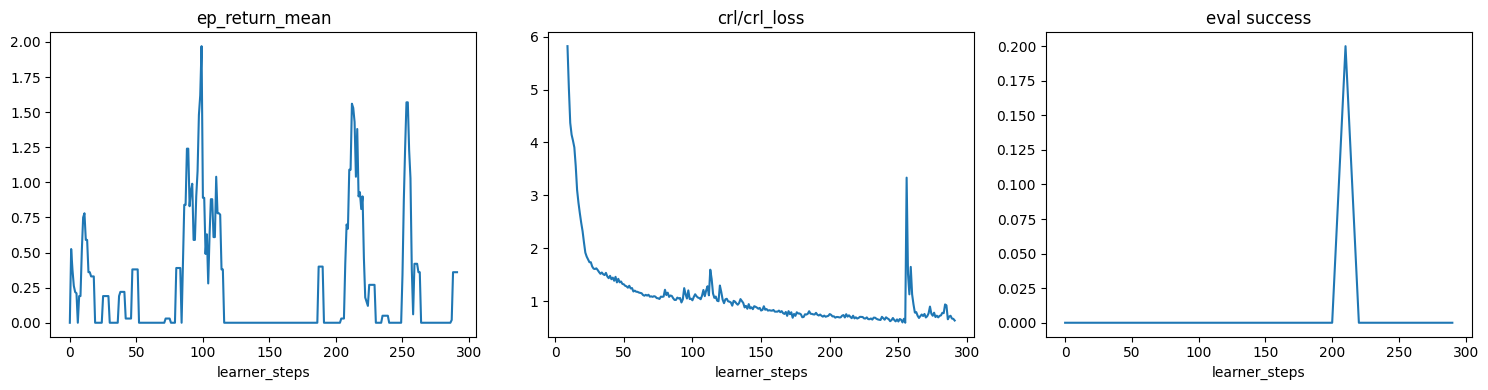

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

learner_df = pd.read_csv(os.path.join(run_dir, 'logs', 'learner', 'logs.csv'))
eval_df = pd.read_csv(os.path.join(run_dir, 'logs', 'eval', 'logs.csv'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(learner_df['learner_steps'], learner_df['ep_return_mean'])
axes[0].set_title('ep_return_mean')
axes[1].plot(learner_df['learner_steps'], learner_df['crl/crl_loss'])
axes[1].set_title('crl/crl_loss')
axes[2].plot(eval_df['learner_steps'], eval_df['success'])
axes[2].set_title('eval success')
for ax in axes:
  ax.set_xlabel('learner_steps')
fig.tight_layout()
plt.show()